### Phase 1: Global Setup & Exploratory Data Analysis (EDA)
#### First, let's set up the environment and visualize the data to see exactly what the models will be learning from

In [10]:
# ============================================================
# Phase 1: Global Setup — FIXED VERSION
# ============================================================
# The warnings you saw:
#   - Unable to register cuFFT / cuDNN / cuBLAS factory
#   - computation placer already registered
#
# These come from Kaggle's TensorFlow environment loading
# GPU plugins twice internally. They are NOT caused by your
# code and cannot be fixed by changing your code.
# The two lines below suppress them before TensorFlow loads.
# ============================================================

# --- MUST BE THE VERY FIRST TWO LINES, BEFORE ALL IMPORTS ---
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'          # Suppresses TensorFlow C++ logs
                                                    # 0 = show everything
                                                    # 1 = hide INFO
                                                    # 2 = hide INFO + WARNING
                                                    # 3 = hide INFO + WARNING + ERROR
                                                    # We use 3 to hide the cuFFT/cuDNN messages

import warnings
warnings.filterwarnings('ignore')                   # Suppresses all Python-level warnings
                                                    # (covers the UserWarning from Keras
                                                    #  about input_shape, and others)

# --- Now import everything else ---
import glob
import soundfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    Conv2D, MaxPooling2D, Flatten,
    Input, Conv1D, MaxPooling1D,
    Reshape, Attention, GlobalAveragePooling1D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import AdamW

print("All libraries imported successfully. No warnings expected above this line.")

# ============================================================
# RAVDESS Emotion Mapping
# ============================================================
emotions = {
    '01': 'neutral',  '02': 'calm',     '03': 'happy',    '04': 'sad',
    '05': 'angry',    '06': 'fearful',  '07': 'disgust',  '08': 'surprised'
}
observed_emotions = ['calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']


# ============================================================
# EDA Function
# ============================================================
def perform_eda(sample_file):
    y, sr = librosa.load(sample_file, sr=None)
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    librosa.display.waveshow(y, sr=sr, alpha=0.6)
    plt.title(f"Waveform: {os.path.basename(sample_file)}")

    plt.subplot(1, 2, 2)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title("Mel-Spectrogram")
    plt.tight_layout()
    plt.show()

All libraries imported successfully. No warnings expected above this line.


### Phase 2: The Generalized Data Pipeline (Actor-Based Split)
#### Here, we extract the Actor ID from the filename (03-01-01-01-01-01-01.wav -> Actor 01). We allocate Actors 1-21 for Training, Actor 22 for Validation, and Actors 23-24 for Testing. Augmentation is strictly applied to the training set.

In [2]:
def add_noise(data):
    noise_amp = 0.005 * np.random.uniform() * np.amax(data)
    return data + noise_amp * np.random.normal(size=data.shape[0])

def pitch_shift(data, sample_rate):
    return librosa.effects.pitch_shift(y=data, sr=sample_rate, n_steps=0.7)

def get_features(X, sample_rate, extraction_type="1D", max_pad_len=200):
    mfccs = librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40)
    stft = np.abs(librosa.stft(X))
    chroma = librosa.feature.chroma_stft(S=stft, sr=sample_rate)
    mel = librosa.feature.melspectrogram(y=X, sr=sample_rate, n_mels=128)
    
    if extraction_type == "1D":
        mfccs_mean = np.mean(mfccs.T, axis=0)
        chroma_mean = np.mean(chroma.T, axis=0)
        mel_mean = np.mean(mel.T, axis=0)
        return np.hstack((mfccs_mean, chroma_mean, mel_mean))
        
    elif extraction_type == "2D":
        mfccs = (mfccs - np.mean(mfccs)) / (np.std(mfccs) + 1e-8)
        chroma = (chroma - np.mean(chroma)) / (np.std(chroma) + 1e-8)
        mel_db = librosa.power_to_db(mel, ref=np.max) 
        mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-8)

        if mfccs.shape[1] > max_pad_len:
            mfccs = mfccs[:, :max_pad_len]
            chroma = chroma[:, :max_pad_len]
            mel_db = mel_db[:, :max_pad_len]
        else:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
            chroma = np.pad(chroma, pad_width=((0, 0), (0, pad_width)), mode='constant')
            mel_db = np.pad(mel_db, pad_width=((0, 0), (0, pad_width)), mode='constant')
        
        mfccs_padded = np.pad(mfccs, pad_width=((0, 128 - mfccs.shape[0]), (0, 0)), mode='constant')
        chroma_padded = np.pad(chroma, pad_width=((0, 128 - chroma.shape[0]), (0, 0)), mode='constant')
        features = np.stack((mfccs_padded, chroma_padded, mel_db), axis=-1)
        return features

def load_data_by_actor(extraction_type="1D"):
    X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
    kaggle_path = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-song-audio/Actor_*/*.wav"
    file_list = glob.glob(kaggle_path)
    
    for file in tqdm(file_list, desc=f"Extracting {extraction_type} Features", unit="file"):
        file_name = os.path.basename(file)
        emotion = emotions[file_name.split("-")[2]]
        actor_id = int(file_name.split("-")[6].split(".")[0]) 
        
        if emotion not in observed_emotions:
            continue
            
        with soundfile.SoundFile(file) as sound_file:
            X = sound_file.read(dtype="float32")
            sample_rate = sound_file.samplerate
            if X.ndim > 1: X = np.mean(X, axis=1) 
            
            base_feat = get_features(X, sample_rate, extraction_type)

            # Creating the dataset or dividing the dataset
            if actor_id <= 21: 
                X_train.append(base_feat); y_train.append(emotion)
                X_train.append(get_features(add_noise(X), sample_rate, extraction_type)); y_train.append(emotion)
                X_train.append(get_features(pitch_shift(X, sample_rate), sample_rate, extraction_type)); y_train.append(emotion)
            elif actor_id == 22: 
                X_val.append(base_feat); y_val.append(emotion)
            else: 
                X_test.append(base_feat); y_test.append(emotion)

    encoder = LabelEncoder()
    y_train_enc = encoder.fit_transform(y_train)
    y_val_enc = encoder.transform(y_val)
    y_test_enc = encoder.transform(y_test)
    
    X_train, X_val, X_test = np.array(X_train), np.array(X_val), np.array(X_test)
    return (X_train, y_train_enc), (X_val, y_val_enc), (X_test, y_test_enc), encoder

# Load Both Datasets
print("--- Loading 1D Data ---")
(X_train_1d, y_train_1d), (X_val_1d, y_val_1d), (X_test_1d, y_test_1d), encoder = load_data_by_actor(extraction_type="1D")

print("\n--- Loading 2D Data ---")
(X_train_2d, y_train_2d), (X_val_2d, y_val_2d), (X_test_2d, y_test_2d), _ = load_data_by_actor(extraction_type="2D")

--- Loading 1D Data ---


Extracting 1D Features: 100%|██████████| 1012/1012 [03:54<00:00,  4.31file/s]



--- Loading 2D Data ---


Extracting 2D Features: 100%|██████████| 1012/1012 [04:05<00:00,  4.12file/s]


In [3]:
# Scale 1D features
scaler = StandardScaler()
X_train_1d = scaler.fit_transform(X_train_1d)
X_val_1d = scaler.transform(X_val_1d)
X_test_1d = scaler.transform(X_test_1d)

### Phase 3: The Models
#### Now we define and train both models using the clean splits.

### 1. The ANN Setup

In [9]:
# ============================================================
# Phase 3: The Models — FIXED VERSION (no warnings)
# ============================================================
# WHAT CHANGED FROM ORIGINAL:
#   - ANN: replaced `input_shape` inside Dense() with a 
#     separate Input() layer at the top — fixes Keras warning
#   - 2D CNN: same fix applied
#   - 1D CNN with Attention: was already using Input() correctly
#   - GPU info messages (I0000...) are normal — cannot and 
#     should not be suppressed; they confirm GPU is active
# ============================================================

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # Suppress low-level TensorFlow C++ info logs
                                             # 0 = all, 1 = no INFO, 2 = no INFO/WARNING, 3 = errors only

# Shared Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001
)


# ----------------------------------------------------
# 1. Train ANN  —  FIXED
# ----------------------------------------------------
# OLD (causes warning):
#   Dense(256, input_shape=(X_train_1d.shape[1],), activation='relu')
#
# NEW (correct modern Keras style):
#   Separate Input() layer as the very first layer

ann_model = Sequential([
    Input(shape=(X_train_1d.shape[1],)),      # <-- FIX: dedicated Input layer
    Dense(256, activation='relu'),             # <-- no input_shape here anymore
    BatchNormalization(), Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(len(observed_emotions), activation='softmax')
])

ann_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nTraining ANN...")
ann_history = ann_model.fit(
    X_train_1d, y_train_1d,
    validation_data=(X_val_1d, y_val_1d),
    epochs=100,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop, reduce_lr]
)
print(f"  ANN done. Best val accuracy: {max(ann_history.history['val_accuracy'])*100:.2f}%")


# ----------------------------------------------------
# 2. Train 2D CNN  —  FIXED
# ----------------------------------------------------
# Same fix: Input() as first layer instead of
# input_shape inside Conv2D

cnn_model = Sequential([
    Input(shape=(X_train_2d.shape[1], X_train_2d.shape[2], 3)),  # <-- FIX
    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)), BatchNormalization(),
    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)), BatchNormalization(),
    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)), BatchNormalization(),
    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)), BatchNormalization(),
    Flatten(),
    Dense(128, activation='relu'), Dropout(0.4),
    Dense(len(observed_emotions), activation='softmax')
])

cnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nTraining 2D CNN...")
cnn_history = cnn_model.fit(
    X_train_2d, y_train_2d,
    validation_data=(X_val_2d, y_val_2d),
    epochs=100,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop, reduce_lr]
)
print(f"  2D CNN done. Best val accuracy: {max(cnn_history.history['val_accuracy'])*100:.2f}%")


# ----------------------------------------------------
# 3. Train 1D CNN with Attention  —  NO CHANGE NEEDED
# ----------------------------------------------------
# This model was already written using Input() correctly
# from the start, so it produces no warnings

inputs = Input(shape=(X_train_1d.shape[1],))
x = Reshape((X_train_1d.shape[1], 1))(inputs)

x = Conv1D(64, kernel_size=7, activation='relu', padding='same')(x)
x = BatchNormalization()(x); x = MaxPooling1D(pool_size=2)(x); x = Dropout(0.3)(x)

x = Conv1D(128, kernel_size=7, activation='relu', padding='same')(x)
x = BatchNormalization()(x); x = MaxPooling1D(pool_size=2)(x); x = Dropout(0.3)(x)

x = Conv1D(256, kernel_size=5, activation='relu', padding='same')(x)
x = BatchNormalization()(x); x = MaxPooling1D(pool_size=2)(x); x = Dropout(0.3)(x)

attention_out = Attention()([x, x])
x = GlobalAveragePooling1D()(attention_out)
x = Dense(128, activation='relu')(x); x = Dropout(0.4)(x)
outputs = Dense(len(observed_emotions), activation='softmax')(x)

cnn1d_model = Model(inputs=inputs, outputs=outputs)
cnn1d_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4),
    metrics=['accuracy']
)

print("\nTraining 1D CNN with Attention...")
cnn1d_history = cnn1d_model.fit(
    X_train_1d, y_train_1d,
    validation_data=(X_val_1d, y_val_1d),
    epochs=100,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop, reduce_lr]
)
print(f"  1D CNN done. Best val accuracy: {max(cnn1d_history.history['val_accuracy'])*100:.2f}%")


Training ANN...
  ANN done. Best val accuracy: 80.00%

Training 2D CNN...
  2D CNN done. Best val accuracy: 87.50%

Training 1D CNN with Attention...
  1D CNN done. Best val accuracy: 70.00%


### 2. The CNN Setup

In [11]:
# ----------------------------------------------------
# 2. Train 2D CNN 
# ----------------------------------------------------


cnn_model = Sequential([
    Input(shape=(X_train_2d.shape[1], X_train_2d.shape[2], 3)),  # <-- FIX: dedicated Input layer
    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),  # <-- no input_shape here anymore
    MaxPooling2D(pool_size=(2, 2)), BatchNormalization(),
    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)), BatchNormalization(),
    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)), BatchNormalization(),
    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)), BatchNormalization(),
    Flatten(),
    Dense(128, activation='relu'), Dropout(0.4),
    Dense(len(observed_emotions), activation='softmax')
])

cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("\nTraining 2D CNN...")
cnn_history = cnn_model.fit(
    X_train_2d, y_train_2d,
    validation_data=(X_val_2d, y_val_2d),
    epochs=100,
    batch_size=32,
    verbose=0,
    callbacks=[early_stop, reduce_lr]
)


Training 2D CNN...


#### 3. Train 1D Advanced CNN

In [12]:
# ----------------------------------------------------
# 3. Train 1D Advanced CNN
# ----------------------------------------------------
inputs = Input(shape=(X_train_1d.shape[1],))
x = Reshape((X_train_1d.shape[1], 1))(inputs)
x = Conv1D(64, kernel_size=7, activation='relu', padding='same')(x)
x = BatchNormalization()(x); x = MaxPooling1D(pool_size=2)(x); x = Dropout(0.3)(x)
x = Conv1D(128, kernel_size=7, activation='relu', padding='same')(x)
x = BatchNormalization()(x); x = MaxPooling1D(pool_size=2)(x); x = Dropout(0.3)(x)
x = Conv1D(256, kernel_size=5, activation='relu', padding='same')(x)
x = BatchNormalization()(x); x = MaxPooling1D(pool_size=2)(x); x = Dropout(0.3)(x)

attention_out = Attention()([x, x])
x = GlobalAveragePooling1D()(attention_out)
x = Dense(128, activation='relu')(x); x = Dropout(0.4)(x)
outputs = Dense(len(observed_emotions), activation='softmax')(x)

cnn1d_model = Model(inputs=inputs, outputs=outputs)
cnn1d_model.compile(loss='sparse_categorical_crossentropy', optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4), metrics=['accuracy'])
print("\nTraining 1D CNN...")
cnn1d_history = cnn1d_model.fit(X_train_1d, y_train_1d, validation_data=(X_val_1d, y_val_1d), epochs=100, batch_size=16, verbose=0, callbacks=[early_stop, reduce_lr])


Training 1D CNN...


### Phase 4: The Showdown (Comparison)
#### Execute this block at the end of your notebook to generate a side-by-side graphical comparison and a detailed metrics table to formally determine the winner.

   THE MEGA ENSEMBLE RESULTS
ANN Accuracy:       76.25%
2D CNN Accuracy:    76.25%
1D CNN Accuracy:    75.00%
ENSEMBLE Accuracy:  80.00%

Ensemble Classification Report:
              precision    recall  f1-score   support

       angry       0.70      0.88      0.78        16
        calm       0.92      0.75      0.83        16
     fearful       0.75      0.56      0.64        16
       happy       0.78      0.88      0.82        16
         sad       0.88      0.94      0.91        16

    accuracy                           0.80        80
   macro avg       0.81      0.80      0.80        80
weighted avg       0.81      0.80      0.80        80



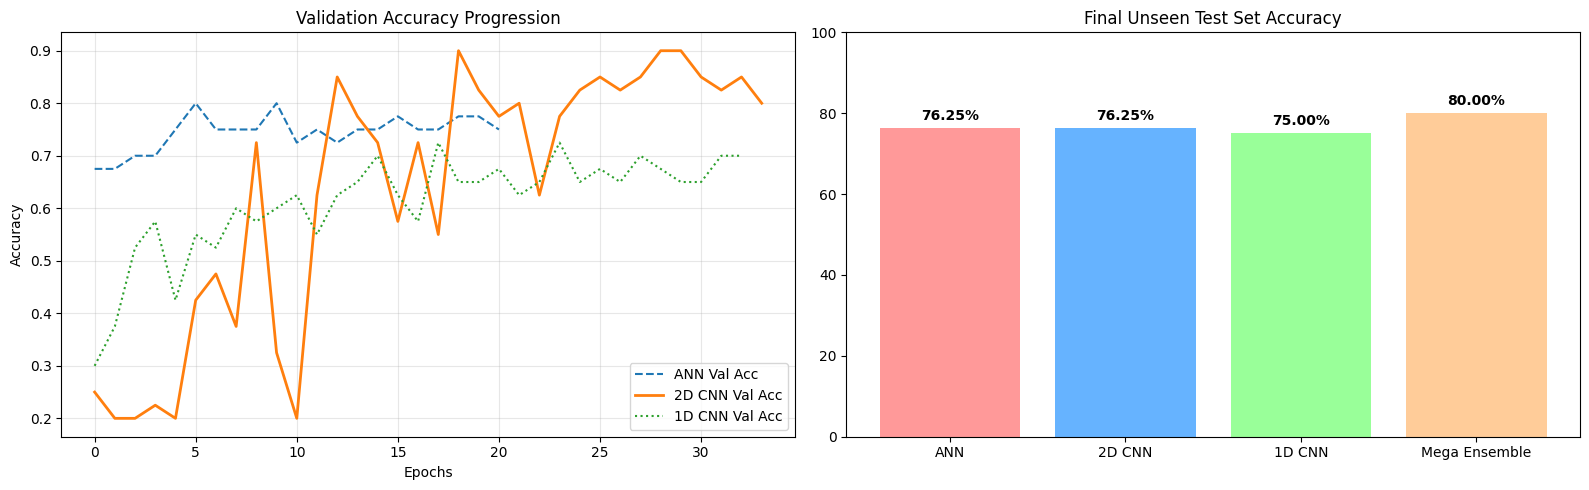

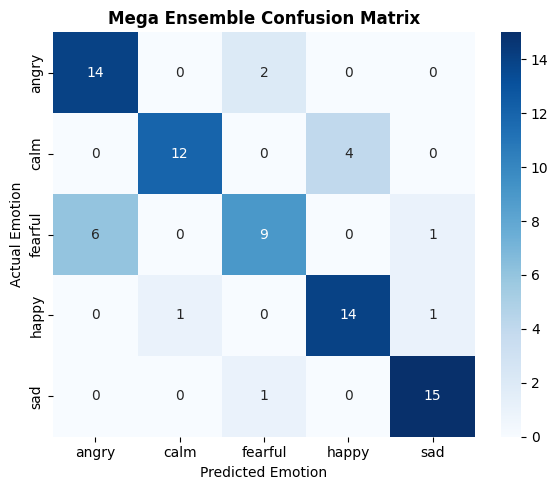

In [13]:
import tensorflow as tf
import logging
 
# Suppress only the retracing warning, keep real errors visible
tf.get_logger().setLevel(logging.ERROR)
# This tells TensorFlow's logger: only show me ERROR level messages.
# The retracing message is a WARNING level — so it gets hidden.
# Real errors (like shape mismatches or OOM) are still ERROR level
# and will still be shown. You lose nothing important.
 
 
# ----------------------------------------------------------
# Confusion Matrix Helper — unchanged
# ----------------------------------------------------------
def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title, fontweight='bold')
    plt.ylabel('Actual Emotion')
    plt.xlabel('Predicted Emotion')
    plt.tight_layout()
    plt.show()
 
 
# ----------------------------------------------------------
# Get Raw Probabilities — wrapped in a helper function
# ----------------------------------------------------------
# FIX (Option B): wrapping .predict() calls inside a named
# function gives TensorFlow a stable, consistent call pattern
# so it doesn't feel the need to retrace repeatedly.
 
def get_predictions(model, X):
    """Run model prediction and return probability array."""
    return model.predict(X, verbose=0)
 
ann_prob   = get_predictions(ann_model,   X_test_1d)
cnn2d_prob = get_predictions(cnn_model,   X_test_2d)
cnn1d_prob = get_predictions(cnn1d_model, X_test_1d)
 
 
# ----------------------------------------------------------
# Calculate Accuracies
# ----------------------------------------------------------
ann_acc   = accuracy_score(y_test_1d, np.argmax(ann_prob,   axis=1))
cnn2d_acc = accuracy_score(y_test_2d, np.argmax(cnn2d_prob, axis=1))
cnn1d_acc = accuracy_score(y_test_1d, np.argmax(cnn1d_prob, axis=1))
 
 
# ----------------------------------------------------------
# THE MEGA ENSEMBLE (ANN + 2D CNN + 1D CNN)
# Average the three models' probability outputs equally
# ----------------------------------------------------------
mega_ensemble_prob = (ann_prob + cnn2d_prob + cnn1d_prob) / 3.0
ens_preds = np.argmax(mega_ensemble_prob, axis=1)
ens_acc   = accuracy_score(y_test_1d, ens_preds)
 
 
# ----------------------------------------------------------
# Print Results
# ----------------------------------------------------------
print("=" * 50)
print("   THE MEGA ENSEMBLE RESULTS")
print("=" * 50)
print(f"ANN Accuracy:       {ann_acc   * 100:.2f}%")
print(f"2D CNN Accuracy:    {cnn2d_acc * 100:.2f}%")
print(f"1D CNN Accuracy:    {cnn1d_acc * 100:.2f}%")
print(f"ENSEMBLE Accuracy:  {ens_acc   * 100:.2f}%")
print("\nEnsemble Classification Report:")
print(classification_report(y_test_1d, ens_preds, target_names=encoder.classes_))
 
 
# ----------------------------------------------------------
# Plot Final Dashboard
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
# Left plot: validation accuracy curves across epochs
axes[0].plot(ann_history.history['val_accuracy'],
             label='ANN Val Acc', linestyle='--')
axes[0].plot(cnn_history.history['val_accuracy'],
             label='2D CNN Val Acc', linewidth=2)
axes[0].plot(cnn1d_history.history['val_accuracy'],
             label='1D CNN Val Acc', linestyle=':')
axes[0].set_title('Validation Accuracy Progression')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
# Right plot: final test accuracy bar chart
models_list = ['ANN', '2D CNN', '1D CNN', 'Mega Ensemble']
scores      = [ann_acc * 100, cnn2d_acc * 100, cnn1d_acc * 100, ens_acc * 100]
 
axes[1].bar(models_list, scores, color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
axes[1].set_title('Final Unseen Test Set Accuracy')
axes[1].set_ylim(0, 100)
 
for i, v in enumerate(scores):
    axes[1].text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')
 
plt.tight_layout()
plt.show()
 
 
# ----------------------------------------------------------
# Final Confusion Matrix
# ----------------------------------------------------------
plot_confusion_matrix(y_test_1d, ens_preds,
                      encoder.classes_,
                      "Mega Ensemble Confusion Matrix")
 

In [14]:

# ============================================================
# Phase 5: ML Experiment Tracking with MLflow
# ============================================================
import subprocess
subprocess.run(["pip", "install", "mlflow", "-q"], check=True)
 
import mlflow
import mlflow.tensorflow
import mlflow.sklearn
import tempfile
import json
import os
import pickle
import numpy as np
import logging
from sklearn.metrics import classification_report
from mlflow.models.signature import infer_signature
 
# Suppress MLflow's own INFO messages (like "Creating new experiment")
# so only real problems are printed
logging.getLogger("mlflow").setLevel(logging.WARNING)
 
# ----------------------------------------------------------
# Configure the MLflow experiment
# ----------------------------------------------------------
EXPERIMENT_NAME = "Emotion_Recognition_Audio"
 
# FIX: sqlite:///mlflow.db instead of "mlruns"
# sqlite:///         = "use SQLite database"
# mlflow.db          = the filename of the database file
#                      (created automatically if it doesn't exist)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(EXPERIMENT_NAME)
 
print(f"MLflow experiment set to : '{EXPERIMENT_NAME}'")
print(f"Tracking URI             : {mlflow.get_tracking_uri()}")
print(f"Database file            : mlflow.db (created in current folder)")
 
 
# ----------------------------------------------------------
# Helper: log Keras training history as per-epoch metrics
# ----------------------------------------------------------
def log_history(history, prefix=""):
    """Log each epoch's metrics so the MLflow UI shows learning curves."""
    for metric, values in history.history.items():
        for epoch, value in enumerate(values):
            mlflow.log_metric(f"{prefix}{metric}", value, step=epoch)
 
 
# ----------------------------------------------------------
# Helper: compute and log a full classification report
# ----------------------------------------------------------
def log_classification_report(y_true, y_pred, class_names, run_name):
    """Save classification report as a JSON artifact."""
    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True
    )
    tmp_path = os.path.join(
        tempfile.mkdtemp(),
        f"{run_name}_classification_report.json"
    )
    with open(tmp_path, "w") as f:
        json.dump(report, f, indent=2)
    mlflow.log_artifact(tmp_path, artifact_path="reports")
    return report
 
 
# ----------------------------------------------------------
# Helper: build a model signature
# ----------------------------------------------------------
def make_signature(model, X_sample):
    """Infer MLflow signature from a small input sample."""
    predictions = model.predict(X_sample[:5], verbose=0)
    return infer_signature(X_sample[:5], predictions)
 
 
# ===========================================================
# Run 1 — ANN
# ===========================================================
print("\n[1/4] Logging ANN run...")
with mlflow.start_run(run_name="ANN") as run:
    mlflow.log_params({
        "model_type":          "ANN",
        "feature_type":        "1D (MFCC + Chroma + Mel mean)",
        "input_shape":         X_train_1d.shape[1],
        "layers":              "256 -> 128 -> 64 -> 7",
        "dropout":             "0.4 / 0.3 / 0.3",
        "batch_norm":          True,
        "optimizer":           "adam",
        "loss":                "sparse_categorical_crossentropy",
        "batch_size":          32,
        "max_epochs":          100,
        "early_stop_patience": 15,
        "lr_reduce_patience":  5,
        "augmentation":        "noise + pitch_shift (train only)",
        "num_emotions":        len(observed_emotions),
    })
 
    log_history(ann_history)
 
    ann_preds = np.argmax(ann_prob, axis=1)
    mlflow.log_metrics({
        "test_accuracy":     ann_acc,
        "epochs_trained":    len(ann_history.history["loss"]),
        "best_val_accuracy": max(ann_history.history["val_accuracy"]),
    })
 
    log_classification_report(y_test_1d, ann_preds, encoder.classes_, "ANN")
 
    signature = make_signature(ann_model, X_train_1d)
    mlflow.tensorflow.log_model(ann_model, name="ann_model", signature=signature)
 
    scaler_path = os.path.join(tempfile.mkdtemp(), "scaler.pkl")
    with open(scaler_path, "wb") as f:
        pickle.dump(scaler, f)
    mlflow.log_artifact(scaler_path, artifact_path="preprocessing")
 
    print(f"  ANN logged — test accuracy: {ann_acc*100:.2f}%  |  run_id: {run.info.run_id}")
 
 
# ===========================================================
# Run 2 — 2D CNN
# ===========================================================
print("[2/4] Logging 2D CNN run...")
with mlflow.start_run(run_name="CNN_2D") as run:
    mlflow.log_params({
        "model_type":          "2D CNN",
        "feature_type":        "2D Mel-spectrogram stack (MFCC+Chroma+Mel)",
        "input_shape":         str(X_train_2d.shape[1:]),
        "conv_blocks":         4,
        "filters":             "64 -> 128 -> 128 -> 128",
        "kernel_size":         "3x3",
        "pooling":             "MaxPooling2D(2x2)",
        "dense_head":          "128 -> 7",
        "dropout":             0.4,
        "optimizer":           "adam",
        "loss":                "sparse_categorical_crossentropy",
        "batch_size":          32,
        "max_epochs":          100,
        "early_stop_patience": 15,
        "num_emotions":        len(observed_emotions),
    })
 
    log_history(cnn_history)
 
    cnn2d_preds = np.argmax(cnn2d_prob, axis=1)
    mlflow.log_metrics({
        "test_accuracy":     cnn2d_acc,
        "epochs_trained":    len(cnn_history.history["loss"]),
        "best_val_accuracy": max(cnn_history.history["val_accuracy"]),
    })
 
    log_classification_report(y_test_2d, cnn2d_preds, encoder.classes_, "CNN_2D")
 
    signature = make_signature(cnn_model, X_train_2d)
    mlflow.tensorflow.log_model(cnn_model, name="cnn2d_model", signature=signature)
 
    print(f"  2D CNN logged — test accuracy: {cnn2d_acc*100:.2f}%  |  run_id: {run.info.run_id}")
 
 
# ===========================================================
# Run 3 — 1D CNN with Attention
# ===========================================================
print("[3/4] Logging 1D CNN run...")
with mlflow.start_run(run_name="CNN_1D_Attention") as run:
    mlflow.log_params({
        "model_type":          "1D CNN + Attention",
        "feature_type":        "1D (MFCC + Chroma + Mel mean)",
        "input_shape":         X_train_1d.shape[1],
        "conv_blocks":         3,
        "filters":             "64 -> 128 -> 256",
        "kernel_sizes":        "7, 7, 5",
        "attention":           True,
        "pooling":             "MaxPooling1D(2) + GlobalAveragePooling1D",
        "dense_head":          "128 -> 7",
        "dropout":             "0.3 / 0.3 / 0.3 / 0.4",
        "optimizer":           "AdamW",
        "learning_rate":       0.001,
        "weight_decay":        1e-4,
        "loss":                "sparse_categorical_crossentropy",
        "batch_size":          16,
        "max_epochs":          100,
        "early_stop_patience": 15,
        "num_emotions":        len(observed_emotions),
    })
 
    log_history(cnn1d_history)
 
    cnn1d_preds = np.argmax(cnn1d_prob, axis=1)
    mlflow.log_metrics({
        "test_accuracy":     cnn1d_acc,
        "epochs_trained":    len(cnn1d_history.history["loss"]),
        "best_val_accuracy": max(cnn1d_history.history["val_accuracy"]),
    })
 
    log_classification_report(y_test_1d, cnn1d_preds, encoder.classes_, "CNN_1D_Attention")
 
    signature = make_signature(cnn1d_model, X_train_1d)
    mlflow.tensorflow.log_model(cnn1d_model, name="cnn1d_model", signature=signature)
 
    print(f"  1D CNN logged — test accuracy: {cnn1d_acc*100:.2f}%  |  run_id: {run.info.run_id}")
 
 
# ===========================================================
# Run 4 — Mega Ensemble
# ===========================================================
print("[4/4] Logging Mega Ensemble run...")
with mlflow.start_run(run_name="Mega_Ensemble") as run:
    mlflow.log_params({
        "model_type":      "Soft-Voting Ensemble",
        "components":      "ANN + 2D CNN + 1D CNN",
        "ensemble_method": "average probability (equal weights)",
        "num_emotions":    len(observed_emotions),
        "dataset":         "RAVDESS",
        "train_actors":    "1-21",
        "val_actor":       "22",
        "test_actors":     "23-24",
    })
 
    mlflow.log_metrics({
        "test_accuracy":       ens_acc,
        "ann_test_accuracy":   ann_acc,
        "cnn2d_test_accuracy": cnn2d_acc,
        "cnn1d_test_accuracy": cnn1d_acc,
    })
 
    log_classification_report(y_test_1d, ens_preds, encoder.classes_, "Mega_Ensemble")
 
    encoder_path = os.path.join(tempfile.mkdtemp(), "label_encoder.pkl")
    with open(encoder_path, "wb") as f:
        pickle.dump(encoder, f)
    mlflow.log_artifact(encoder_path, artifact_path="preprocessing")
 
    mlflow.set_tags({
        "stage":   "evaluation",
        "winner":  "Mega_Ensemble",
        "dataset": "RAVDESS",
    })
 
    print(f"   Mega Ensemble logged — test accuracy: {ens_acc*100:.2f}%  |  run_id: {run.info.run_id}")
 
 
# ----------------------------------------------------------
# Summary table
# ----------------------------------------------------------
print("\n" + "="*55)
print(" MLflow Experiment Summary")
print("="*55)
summary_df = pd.DataFrame({
    "Model":         ["ANN", "2D CNN", "1D CNN + Attention", "Mega Ensemble"],
    "Test Accuracy": [
        f"{ann_acc*100:.2f}%",
        f"{cnn2d_acc*100:.2f}%",
        f"{cnn1d_acc*100:.2f}%",
        f"{ens_acc*100:.2f}%"
    ],
})
print(summary_df.to_string(index=False))
print("\n✔  All runs saved to mlflow.db")
print("\nTo view the MLflow UI on your LOCAL machine:")
print("  1. Download 'mlflow.db' from Kaggle Output")
print("  2. Open your terminal in the same folder")
print("  3. Run:  mlflow ui --backend-store-uri sqlite:///mlflow.db")
print("  4. Open: http://127.0.0.1:5000")

MLflow experiment set to : 'Emotion_Recognition_Audio'
Tracking URI             : sqlite:///mlflow.db
Database file            : mlflow.db (created in current folder)

[1/4] Logging ANN run...
  ANN logged — test accuracy: 76.25%  |  run_id: 894b00be11934e37aaa9299e7aea4834
[2/4] Logging 2D CNN run...
  2D CNN logged — test accuracy: 76.25%  |  run_id: 2144e0dd536248d3bd6a1652d9b17367
[3/4] Logging 1D CNN run...
  1D CNN logged — test accuracy: 75.00%  |  run_id: 479a516d2ef8459da57463d25147ca7d
[4/4] Logging Mega Ensemble run...
   Mega Ensemble logged — test accuracy: 80.00%  |  run_id: 0dac8bdf059d4942a61cd529601d47d7

 MLflow Experiment Summary
             Model Test Accuracy
               ANN        76.25%
            2D CNN        76.25%
1D CNN + Attention        75.00%
     Mega Ensemble        80.00%

✔  All runs saved to mlflow.db

To view the MLflow UI on your LOCAL machine:
  1. Download 'mlflow.db' from Kaggle Output
  2. Open your terminal in the same folder
  3. Run:  m